In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

plt.style.use("default")

In [3]:
df = pd.read_csv("data/final_dataset.csv")

print("Shape:", df.shape)
display(df.head())
display(df.dtypes)

Shape: (196943, 23)


,date,station,TMAX,state,id,elevation,disasters_count,heat_related_disaster_count,heat_related_area_count,heat_related_any,...,p_unemp,p_nohsdp,p_uninsur,p_imperv,p_treec,p_age65,p_asthma,overall_score,hhb_score,pop_state_sum
0,2020-01-01,GHCND:USW00013876,56.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
1,2020-01-02,GHCND:USW00013876,70.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
2,2020-01-03,GHCND:USW00013876,65.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
3,2020-01-04,GHCND:USW00013876,57.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
4,2020-01-05,GHCND:USW00013876,57.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0


date                               object
station                            object
TMAX                              float64
state                              object
id                                 object
elevation                         float64
disasters_count                   float64
heat_related_disaster_count       float64
heat_related_area_count           float64
heat_related_any                  float64
heat_related_counties_affected    float64
state_fips                          int64
p_pov                             float64
p_unemp                           float64
p_nohsdp                          float64
p_uninsur                         float64
p_imperv                          float64
p_treec                           float64
p_age65                           float64
p_asthma                          float64
overall_score                     float64
hhb_score                         float64
pop_state_sum                     float64
dtype: object

In [5]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day_of_year"] = df["date"].dt.dayofyear

display(df[["date", "year", "month", "day_of_year"]].head())

,date,year,month,day_of_year
0,2020-01-01,2020,1,1
1,2020-01-02,2020,1,2
2,2020-01-03,2020,1,3
3,2020-01-04,2020,1,4
4,2020-01-05,2020,1,5


In [6]:
target = "TMAX"

predictors = [
    "elevation",
    "disasters_count",
    "heat_related_disaster_count",
    "heat_related_area_count",
    "heat_related_counties_affected",
    "p_pov",
    "p_unemp",
    "p_nohsdp",
    "p_uninsur",
    "p_imperv",
    "p_treec",
    "p_age65",
    "p_asthma",
    "overall_score",
    "hhb_score",
    "pop_state_sum",
    "year",
    "month",
    "day_of_year"
]

data = df[[target] + predictors].copy()

print(data.shape)
display(data.head())

(196943, 20)


,TMAX,elevation,disasters_count,heat_related_disaster_count,heat_related_area_count,heat_related_counties_affected,p_pov,p_unemp,p_nohsdp,p_uninsur,p_imperv,p_treec,p_age65,p_asthma,overall_score,hhb_score,pop_state_sum,year,month,day_of_year
0,56.0,187.7,0.0,0.0,0.0,0.0,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,1
1,70.0,187.7,0.0,0.0,0.0,0.0,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,2
2,65.0,187.7,0.0,0.0,0.0,0.0,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,3
3,57.0,187.7,0.0,0.0,0.0,0.0,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,4
4,57.0,187.7,0.0,0.0,0.0,0.0,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,5


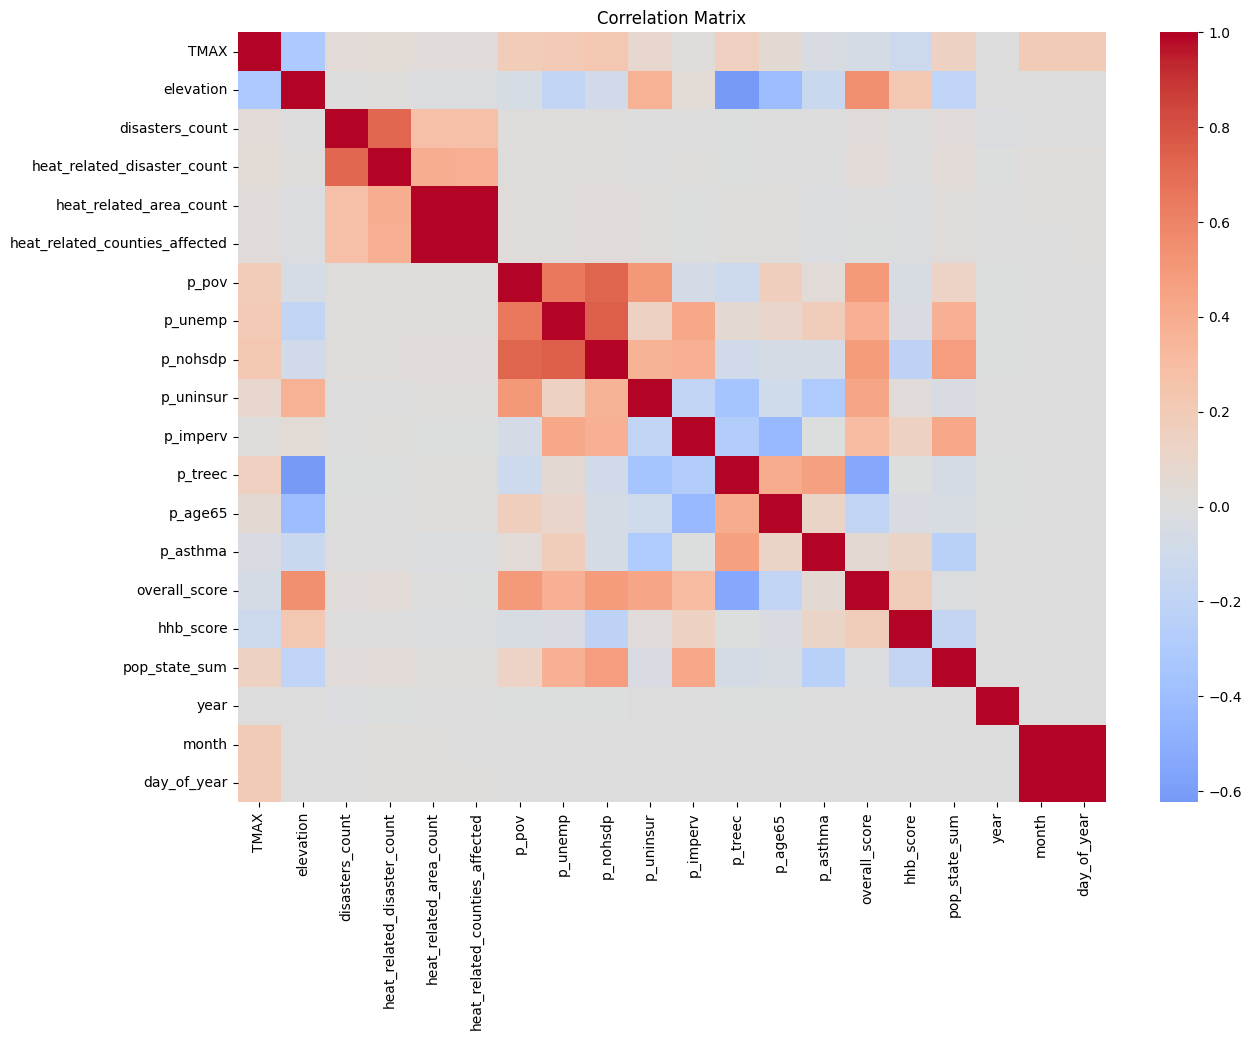

In [7]:
corr_matrix = data.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [8]:
target_corr = corr_matrix[target].sort_values(ascending=False)
display(target_corr)

TMAX                              1.000000
p_nohsdp                          0.229304
p_unemp                           0.205840
month                             0.199629
day_of_year                       0.195824
p_pov                             0.194547
p_treec                           0.158308
pop_state_sum                     0.145039
p_uninsur                         0.085247
p_age65                           0.052735
heat_related_disaster_count       0.045972
disasters_count                   0.030230
heat_related_area_count           0.027667
heat_related_counties_affected    0.027370
p_imperv                          0.015911
year                              0.008038
p_asthma                         -0.038157
overall_score                    -0.056929
hhb_score                        -0.120823
elevation                        -0.313363
Name: TMAX, dtype: float64

In [9]:
X = data[predictors]
y = data[target]

X = sm.add_constant(X)

full_model = sm.OLS(y, X).fit()

print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   TMAX   R-squared:                       0.216
Model:                            OLS   Adj. R-squared:                  0.216
Method:                 Least Squares   F-statistic:                     2850.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:57:15   Log-Likelihood:            -8.5226e+05
No. Observations:              196943   AIC:                         1.705e+06
Df Residuals:                  196923   BIC:                         1.705e+06
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [10]:
print("Overall F-test")
print("F-statistic:", full_model.fvalue)
print("p-value:", full_model.f_pvalue)

if full_model.f_pvalue < 0.05:
    print("Result: Reject H0. At least one predictor is significantly related to TMAX.")
else:
    print("Result: Fail to reject H0. The predictors are not jointly significant.")

Overall F-test
F-statistic: 2849.646715776941
p-value: 0.0
Result: Reject H0. At least one predictor is significantly related to TMAX.


In [11]:
vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_df.sort_values("VIF", ascending=False))

,Variable,VIF
0,const,2.038934e+06
4,heat_related_area_count,7.604558e+02
5,heat_related_counties_affected,7.515752e+02
19,day_of_year,1.431017e+02
18,month,1.431000e+02
8,p_nohsdp,7.494252e+00
6,p_pov,6.708542e+00
10,p_imperv,5.263446e+00
11,p_treec,4.501897e+00
14,overall_score,4.221886e+00


In [18]:
reduced_predictors = [
    "elevation",
    "disasters_count",
    "p_pov",
    "p_unemp",
    "p_nohsdp",
    "p_uninsur",
    "p_imperv",
    "p_treec",
    "p_age65",
    "p_asthma",
    "overall_score",
    "hhb_score",
    "pop_state_sum",
    "year",
    "month",
    "day_of_year"
]

X_reduced = sm.add_constant(data[reduced_predictors])
reduced_model = sm.OLS(y, X_reduced).fit()

print(reduced_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   TMAX   R-squared:                       0.215
Model:                            OLS   Adj. R-squared:                  0.215
Method:                 Least Squares   F-statistic:                     3364.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:15:06   Log-Likelihood:            -8.5239e+05
No. Observations:              196943   AIC:                         1.705e+06
Df Residuals:                  196926   BIC:                         1.705e+06
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            -251.4074     59.007     

In [19]:
partial_f = full_model.compare_f_test(reduced_model)

print("Partial F-test results")
print("F-statistic:", partial_f[0])
print("p-value:", partial_f[1])
print("df difference:", partial_f[2])

if partial_f[1] < 0.05:
    print("Result: Reject H0. The removed variables are jointly significant.")
else:
    print("Result: Fail to reject H0. The removed variables do not significantly improve the model.")

Partial F-test results
F-statistic: 85.63109380788046
p-value: 2.2956348464991192e-55
df difference: 3.0
Result: Reject H0. The removed variables are jointly significant.


In [20]:
data["fitted"] = full_model.fittedvalues
data["residuals"] = full_model.resid
data["std_residuals"] = full_model.get_influence().resid_studentized_internal

display(data[[target, "fitted", "residuals", "std_residuals"]].head())

,TMAX,fitted,residuals,std_residuals
0,56.0,67.134415,-11.134415,-0.607451
1,70.0,67.047587,2.952413,0.161072
2,65.0,66.960759,-1.960759,-0.106971
3,57.0,66.873931,-9.873931,-0.538682
4,57.0,66.787103,-9.787103,-0.533945


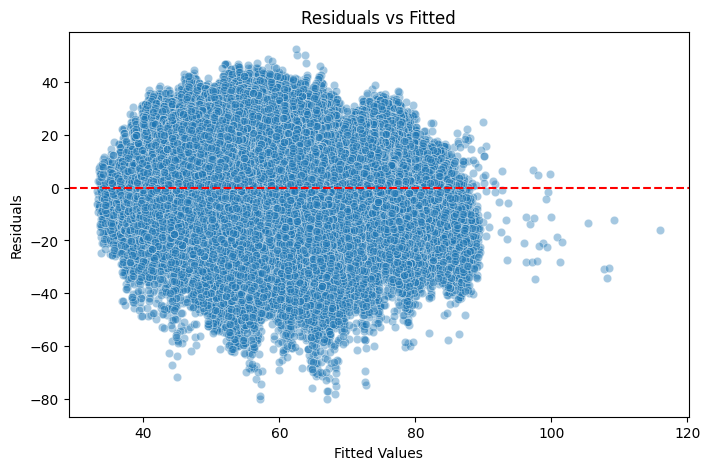

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=data["fitted"], y=data["residuals"], alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

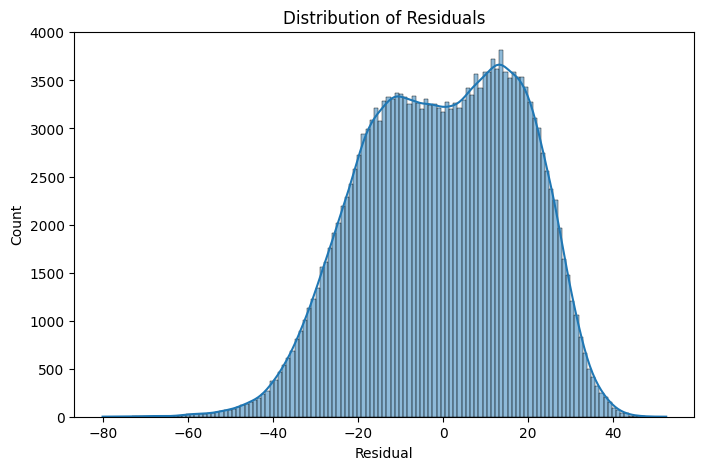

In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(data["residuals"], kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.show()

<Figure size 600x600 with 0 Axes>

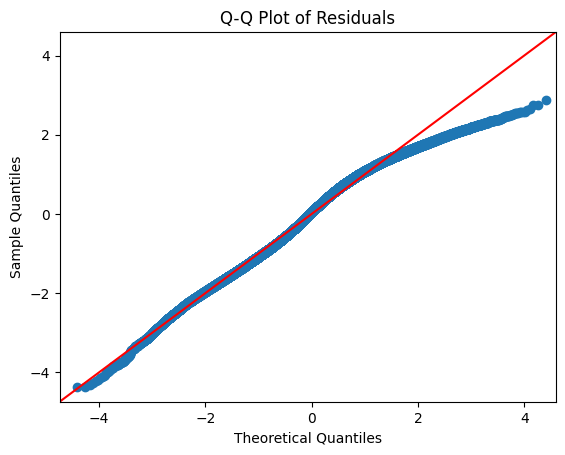

In [23]:
plt.figure(figsize=(6, 6))
sm.qqplot(data["residuals"], line="45", fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [25]:
bp_test = het_breuschpagan(full_model.resid, full_model.model.exog)

bp_results = pd.DataFrame({
    "Statistic": ["LM Statistic", "LM-Test p-value", "F-Statistic", "F-Test p-value"],
    "Value": bp_test
})

display(bp_results)

,Statistic,Value
0,LM Statistic,13675.055778
1,LM-Test p-value,0.000000
2,F-Statistic,773.366651
3,F-Test p-value,0.000000


From the Breusch-Pagan test for heteroscedasticity, since $p < .05$, there is evidence of heteroscedasticity

In [26]:
jb_stat, jb_pvalue, skew, kurtosis = sm.stats.jarque_bera(full_model.resid)

print("Jarque-Bera Statistic:", jb_stat)
print("Jarque-Bera p-value:", jb_pvalue)
print("Skew:", skew)
print("Kurtosis:", kurtosis)

if jb_pvalue < 0.05:
    print("Residuals deviate significantly from normality.")
else:
    print("Residuals do not significantly deviate from normality.")

Jarque-Bera Statistic: 4675.066076975437
Jarque-Bera p-value: 0.0
Skew: -0.2199001533155641
Kurtosis: 2.3865737785367545
Residuals deviate significantly from normality.


In [28]:
dw = sm.stats.stattools.durbin_watson(full_model.resid)
print("Durbin-Watson:", dw)

if dw < 1.5:
    print("Evidence of positive autocorrelation.")
elif dw > 2.5:
    print("Evidence of negative autocorrelation.")
else:
    print("No significant autocorrelation.")

Durbin-Watson: 0.15708427112583354
Evidence of positive autocorrelation.


In [30]:
coef_table = pd.DataFrame({
    "Coefficient": full_model.params,
    "Std_Error": full_model.bse,
    "t_value": full_model.tvalues,
    "p_value": full_model.pvalues
})

display(coef_table.sort_values("p_value"))

,Coefficient,Std_Error,t_value,p_value
p_uninsur,1.144439e+00,2.278394e-02,50.230086,0.000000e+00
elevation,-7.614594e-03,6.956908e-05,-109.453713,0.000000e+00
p_age65,-1.297183e+00,2.664716e-02,-48.679977,0.000000e+00
p_asthma,-2.592424e+00,8.884369e-02,-29.179610,8.828990e-187
month,3.844212e+00,1.432719e-01,26.831595,2.671604e-158
overall_score,2.688457e+01,1.102958e+00,24.374965,4.937799e-131
p_treec,1.286951e-01,5.343627e-03,24.083843,5.662375e-128
p_unemp,1.503832e+00,8.108638e-02,18.546048,1.020680e-76
day_of_year,-8.682778e-02,4.685118e-03,-18.532676,1.308224e-76
heat_related_disaster_count,1.098986e+01,6.892697e-01,15.944206,3.395093e-57
